# **스테이지 4. EDA**

In [ ]:
# drive에 연결합니다.
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 현재 데이터가 있는 공간으로 작업 경로를 변경해줍니다.
%cd "/content/drive/MyDrive/AI/Data Set/신용카드_사용자 연체 예측"

Mounted at /content/drive
/content/drive/MyDrive/ML_Data/Dacon/데이크루6기/신용카드/open


In [ ]:
# pandas 패키지를 pd라는 별칭으로 불러옵니다.
import pandas as pd

# train 데이터를 불러옵니다.
train = pd.read_csv('train.csv')
# test 데이터를 불러옵니다.
test = pd.read_csv('test.csv')
# submission 데이터를 불러옵니다.
submission = pd.read_csv('sample_submission.csv')

데이터를 살펴보는 것을 다른 말로는 <font color=green>**EDA (Exploratory Data Analysis)**</font>라고도 합니다.<br>

데이터 분석을 하기에 앞서서 EDA 작업을 하는 것은 아주 중요한 일입니다!

 EDA가 왜 중요할까?

EDA는 데이터 분석 이전에 데이터셋을 요약하고 정리해서 중요한 특징들을<br>
파악하는 작업을 말합니다.

EDA를 잘한다면 어떤 변수가 이번 데이터 분석에 중요한지, 데이터들에는 어떠한<br>
패턴들이 존재하는지 등을 파악할 수 있습니다. 이런 결과는 당연히 후에 예측 모델<br>
선정 및 학습 과정에서도 큰 영향을 끼치기 때문에 예측의 품질을 높일 수 있죠!

EDA는 어떻게 해야 하는 걸까?

정해진 EDA 방법은 없습니다. 그러나, 일반적으로 데이터를 요약할 수 있는<br>
정보들(e.g. 평균, 상관관계, ...)을 활용하거나 데이터 시각화를 통해서<br>
데이터들 사이의 관계와 패턴을 파악하는 작업을 많이 합니다.

## **Step 1. 종속 변수 확인**

In [ ]:
# matplotlib.pyplot을 별칭 plt로 불러옵니다.
import matplotlib.pyplot as plt

# seaborn을 별칭 sns로 불러옵니다.
import seaborn as sns

In [ ]:
rc = {
    "axes.facecolor": "#F6F6F6",
    "figure.facecolor": "#B8B8B8",
    "axes.edgecolor": "#000000",
    "grid.color": "#C4C4C4",
    "axes.labelcolor": "#000000",
    "xtick.color": "#000000",
    "ytick.color": "#000000",
    "grid.alpha": 0.4
}

sns.set(rc=rc)

<Axes: xlabel='credit', ylabel='count'>

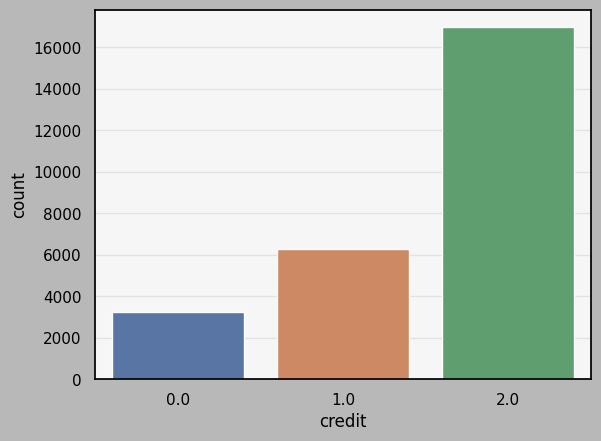

In [ ]:
sns.countplot(train, x="credit")

## **Step 2. 수치형 데이터 EDA**

In [ ]:
# FLAG_MOBIL, work_phone, phone, email의 타입을 바꿔줍니다.

train['FLAG_MOBIL'] = train['FLAG_MOBIL'].astype('object')
train['work_phone'] = train['work_phone'].astype('object')
train['phone'] = train['phone'].astype('object')
train['email'] = train['email'].astype('object')

In [ ]:
train_num = train.select_dtypes(include="number")
train_num["credit"] = train["credit"]
train_cat = train.select_dtypes(exclude="number")
train_cat["credit"] = train["credit"]

In [ ]:
# train_num 데이터의 summary 결과를 확인해보세요
train_num.describe()

,index,child_num,income_total,DAYS_BIRTH,DAYS_EMPLOYED,family_size,begin_month,credit
count,26457.000000,26457.000000,2.645700e+04,26457.000000,26457.000000,26457.000000,26457.000000,26457.000000
mean,13228.000000,0.428658,1.873065e+05,43.720696,6.023369,2.196848,26.123294,1.519560
std,7637.622372,0.747326,1.018784e+05,11.511203,6.493536,0.916717,16.559550,0.702283
min,0.000000,0.000000,2.700000e+04,21.109589,0.000000,1.000000,-0.000000,0.000000
25%,6614.000000,0.000000,1.215000e+05,34.098630,1.115068,2.000000,12.000000,1.000000
50%,13228.000000,0.000000,1.575000e+05,42.594521,4.216438,2.000000,24.000000,2.000000
75%,19842.000000,1.000000,2.250000e+05,53.235616,8.638356,3.000000,39.000000,2.000000
max,26456.000000,19.000000,1.575000e+06,68.909589,43.049315,20.000000,60.000000,2.000000


### **1. boxplot**

<img src="https://miro.medium.com/max/9000/1*2c21SkzJMf3frPXPAR_gZA.png">

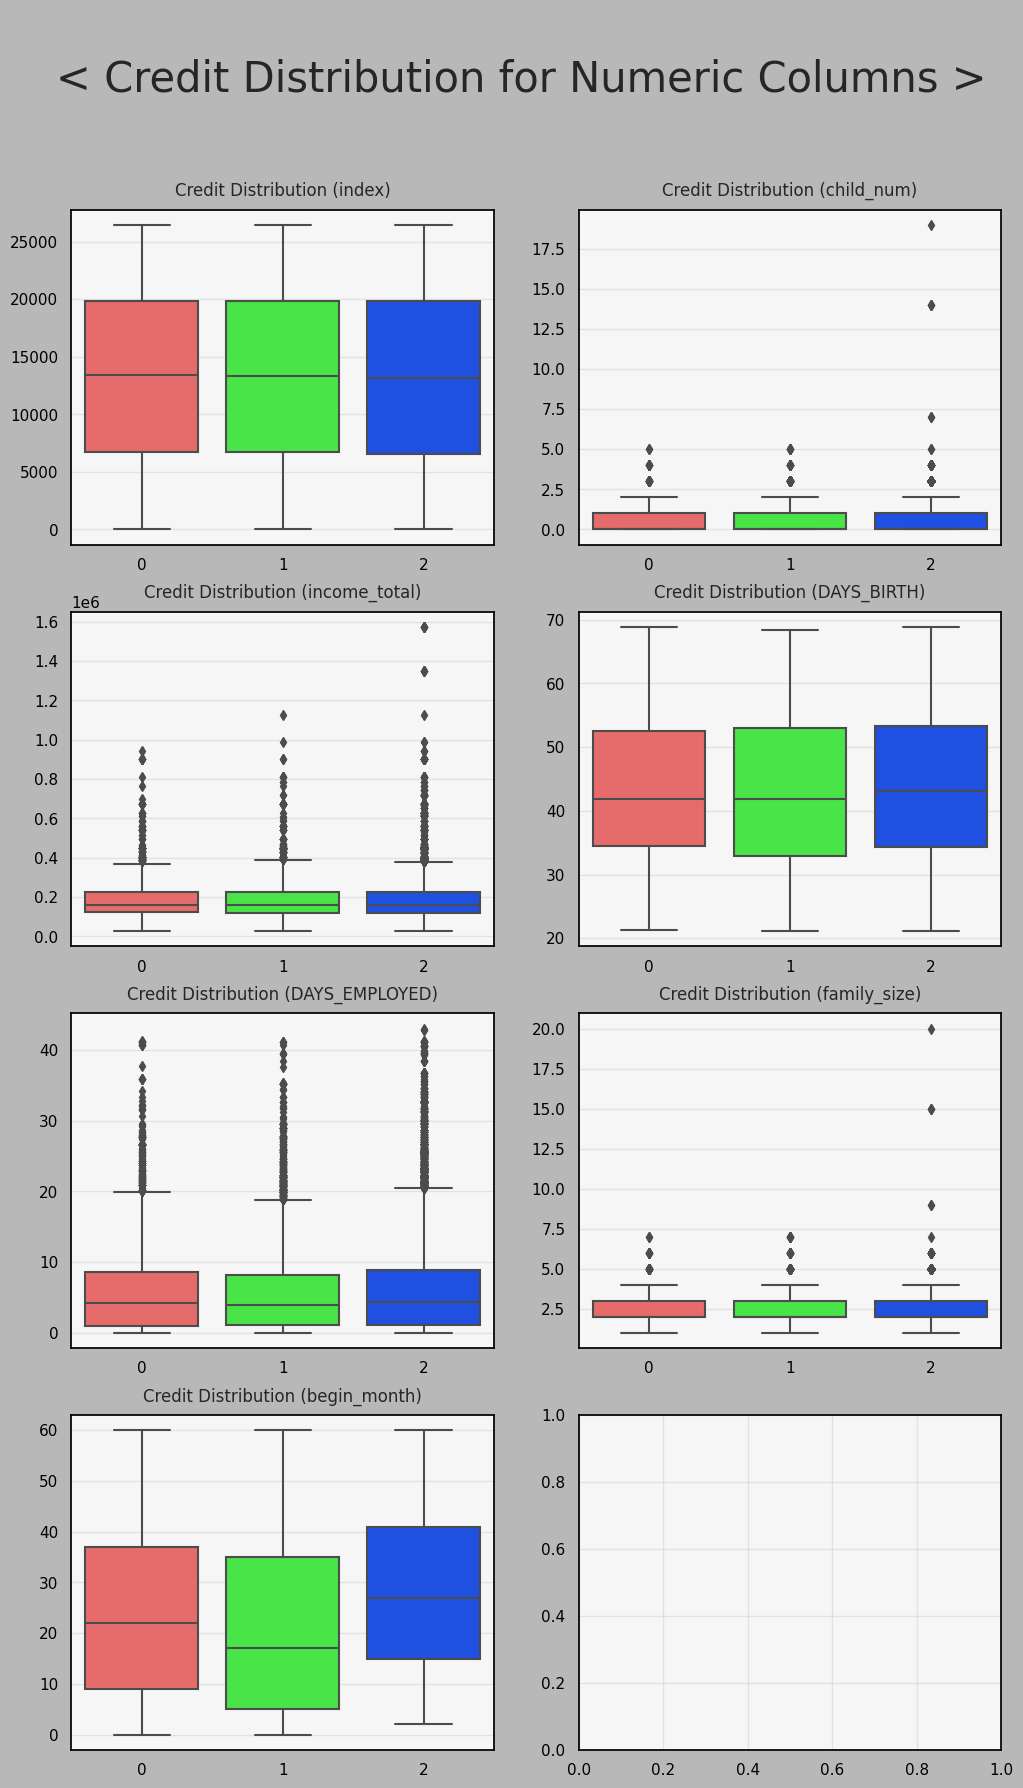

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12,20))
axes = axes.flatten()

color = ["#FA5858", "#2EFE2E", "#0040FF"]

num_eda_cols = train_num.columns[:-1]

for i, col in enumerate(num_eda_cols):
  sns.boxplot(data=train_num, y=col, x="credit", order=[0, 1, 2],
              ax=axes[i], palette=color)
  axes[i].set_title(f"Credit Distribution ({col})", pad=10)
  axes[i].set_xlabel('')
  axes[i].set_ylabel('')

plt.suptitle("\n< Credit Distribution for Numeric Columns >", fontsize=30)
plt.show()

### **2. heatmap**

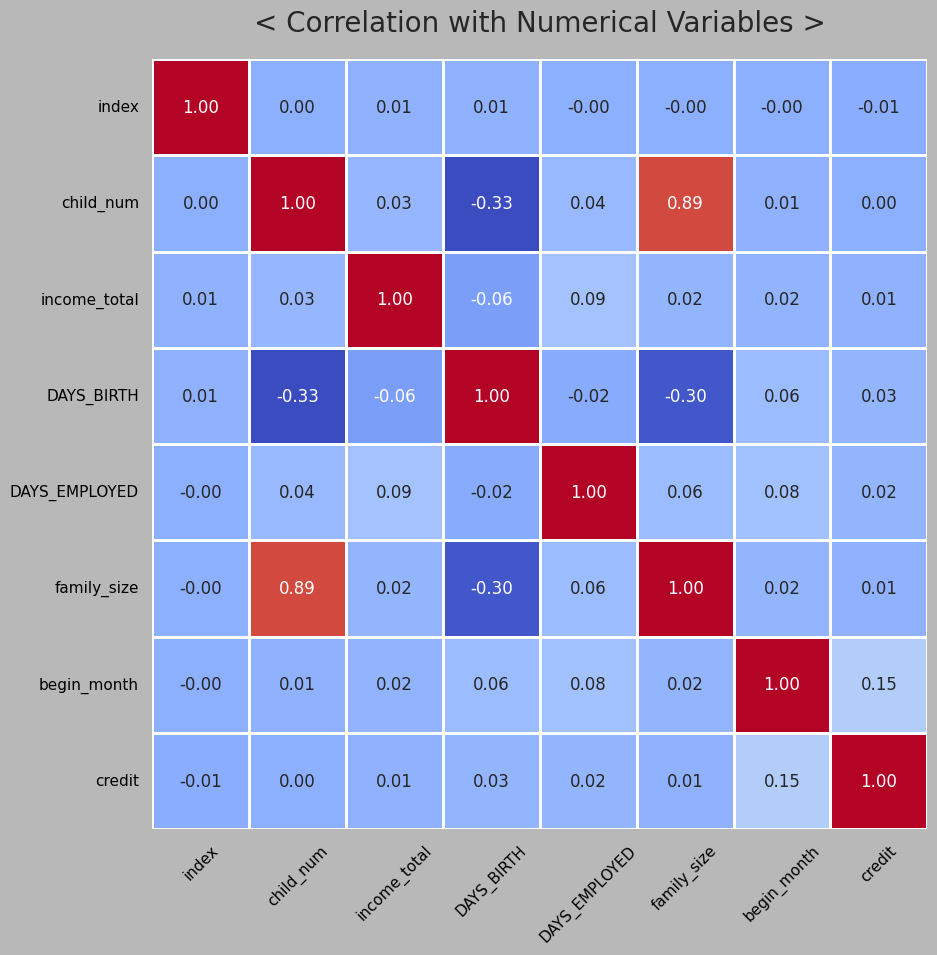

In [ ]:
# 추출한 상관관계를 바탕으로 heatmap을 그려서 확인해보세요

plt.figure(figsize=(10,10))
sns.heatmap(train_num.corr(), cmap='coolwarm', annot=True, fmt=".2f", linewidths=1, cbar=False)
plt.xticks(rotation=45)
plt.title("< Correlation with Numerical Variables >", pad=20, fontsize=20)
plt.show()

**결과 해석**<br>
`child_num`, `family_size`는 <font color=blue>**강한 양의 상관관계**</font>를 보이고 있네요!<br>
그리고 `DAYS_BIRTH` 변수가 `child_num`, `family_size`와 <font color=red>**약한 음의 상관관계**</font>를<br>
가지고 있는 걸 확인할 수 있어요.<br>
나머지 변수들은 선형적인 상관관계는 없는 걸 알 수 있네요.

### **3. pairplot**

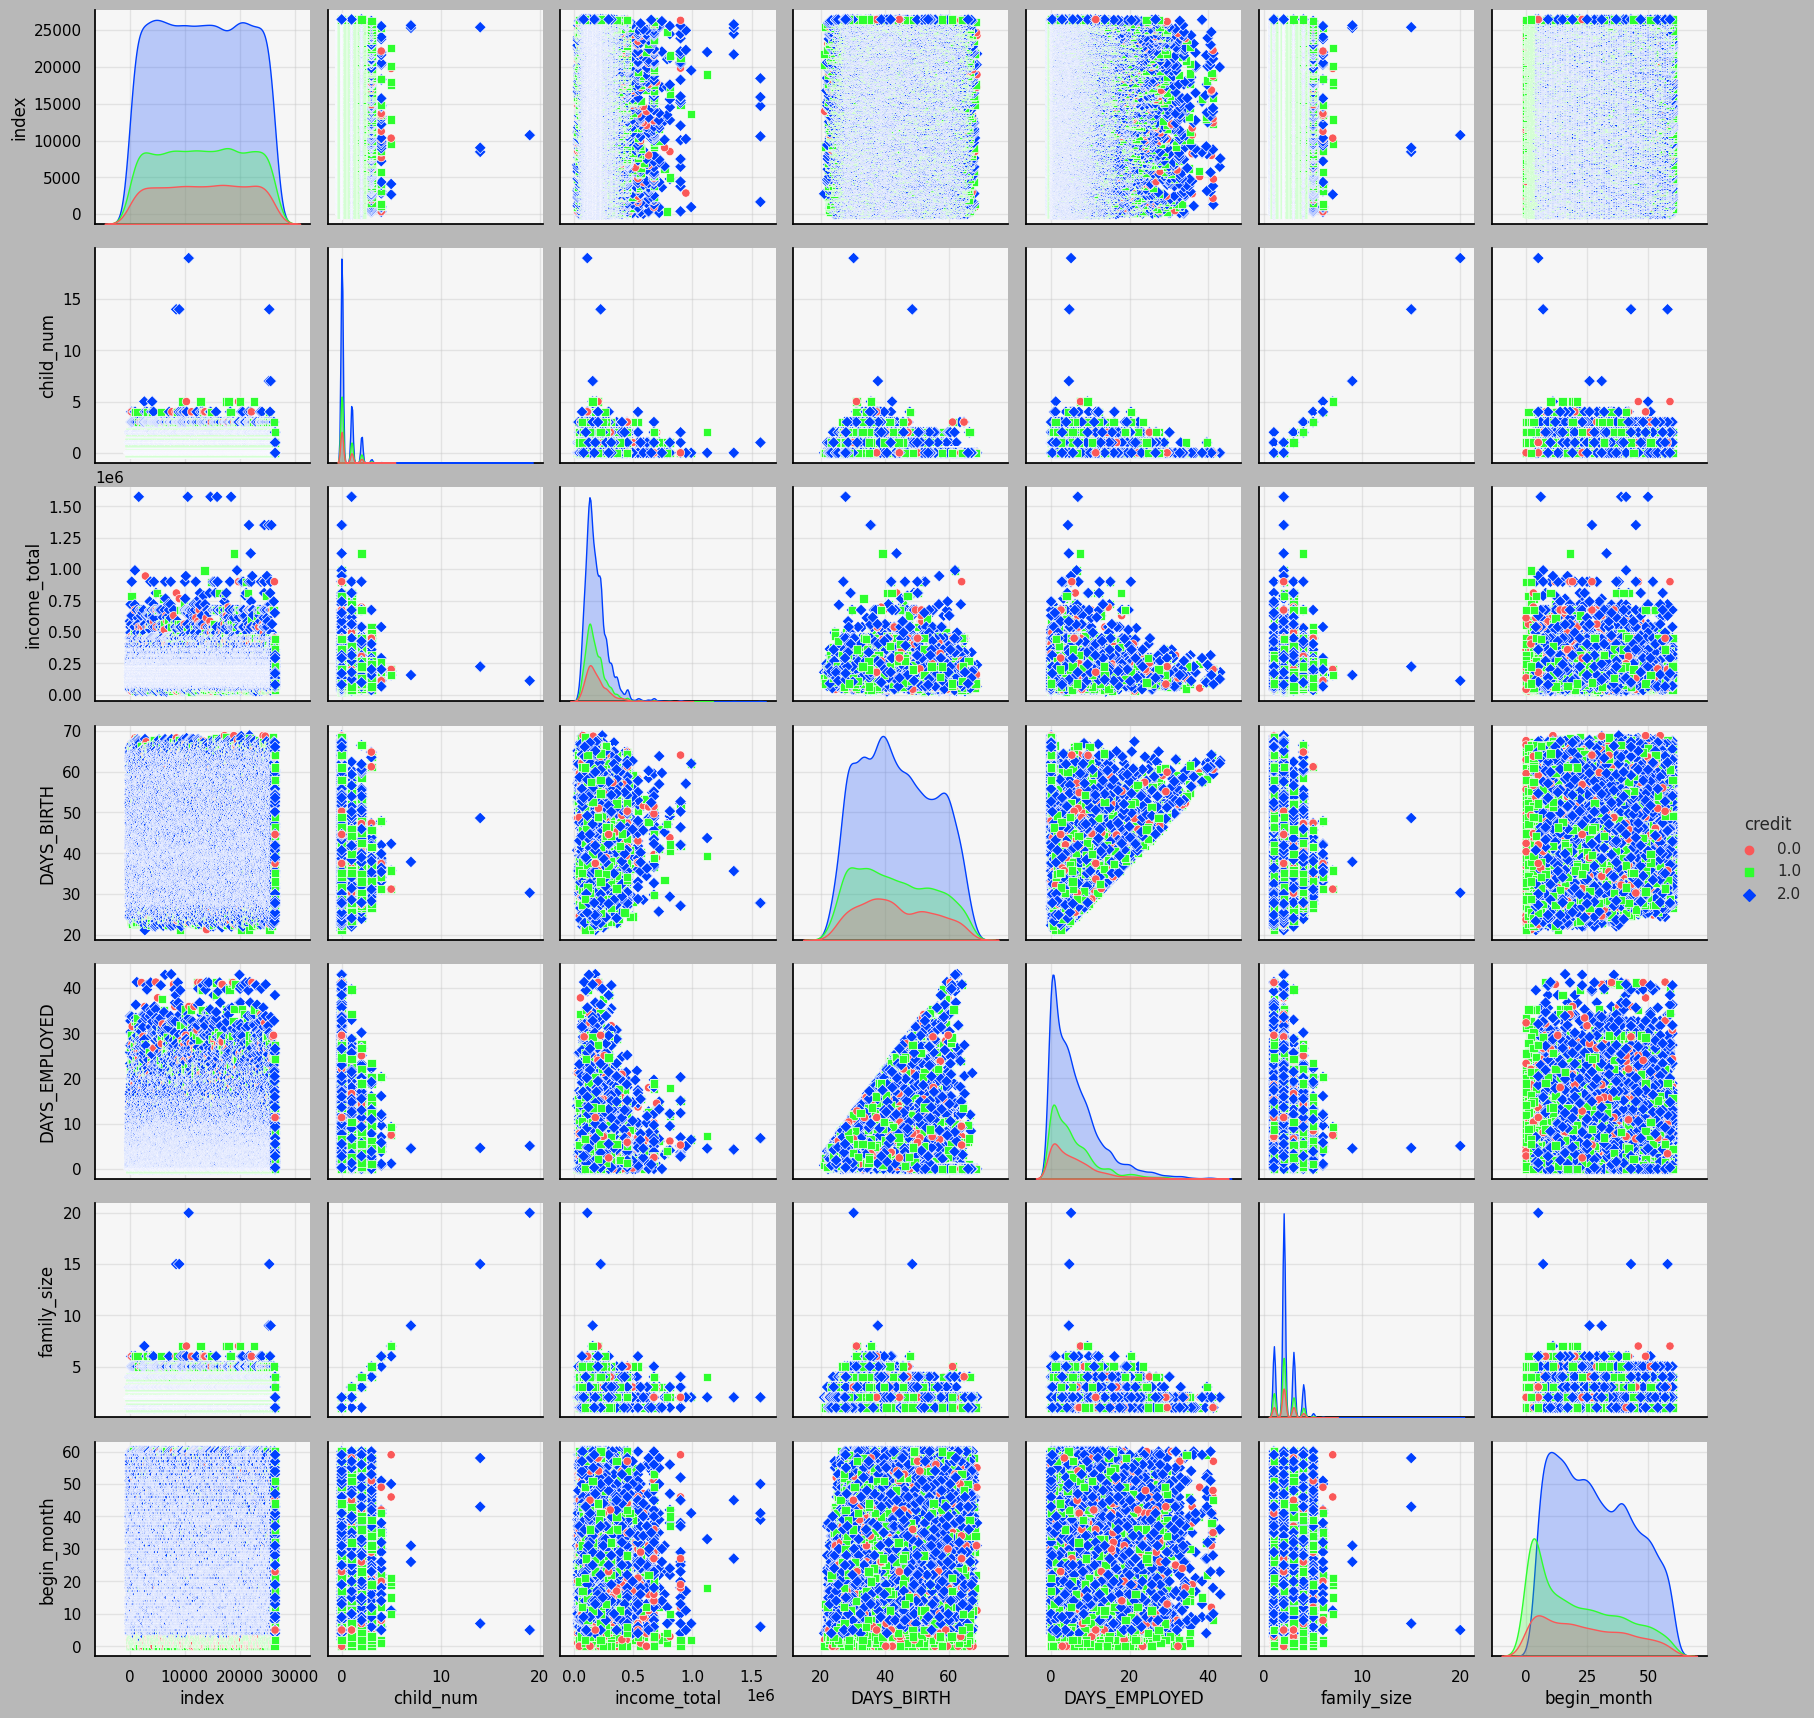

In [ ]:
# train_num 데이터로 변수들 간의 상관관계를 더 자세히 확인해보세요

color = ["#FA5858", "#2EFE2E", "#0040FF"]

sns.pairplot(train_num, hue="credit", markers=["o", "s", "D"], palette=color)

이로써 수치형 변수들간에 유의미한 상관관계가 존재하지 않는 것꺼지 확인하였습니다!<br>

이제 카테고리형 변수들을 EDA 해보도록 하겠습니다!

## **Step 3. 카테고리형 데이터 EDA**

### **1. histplot**

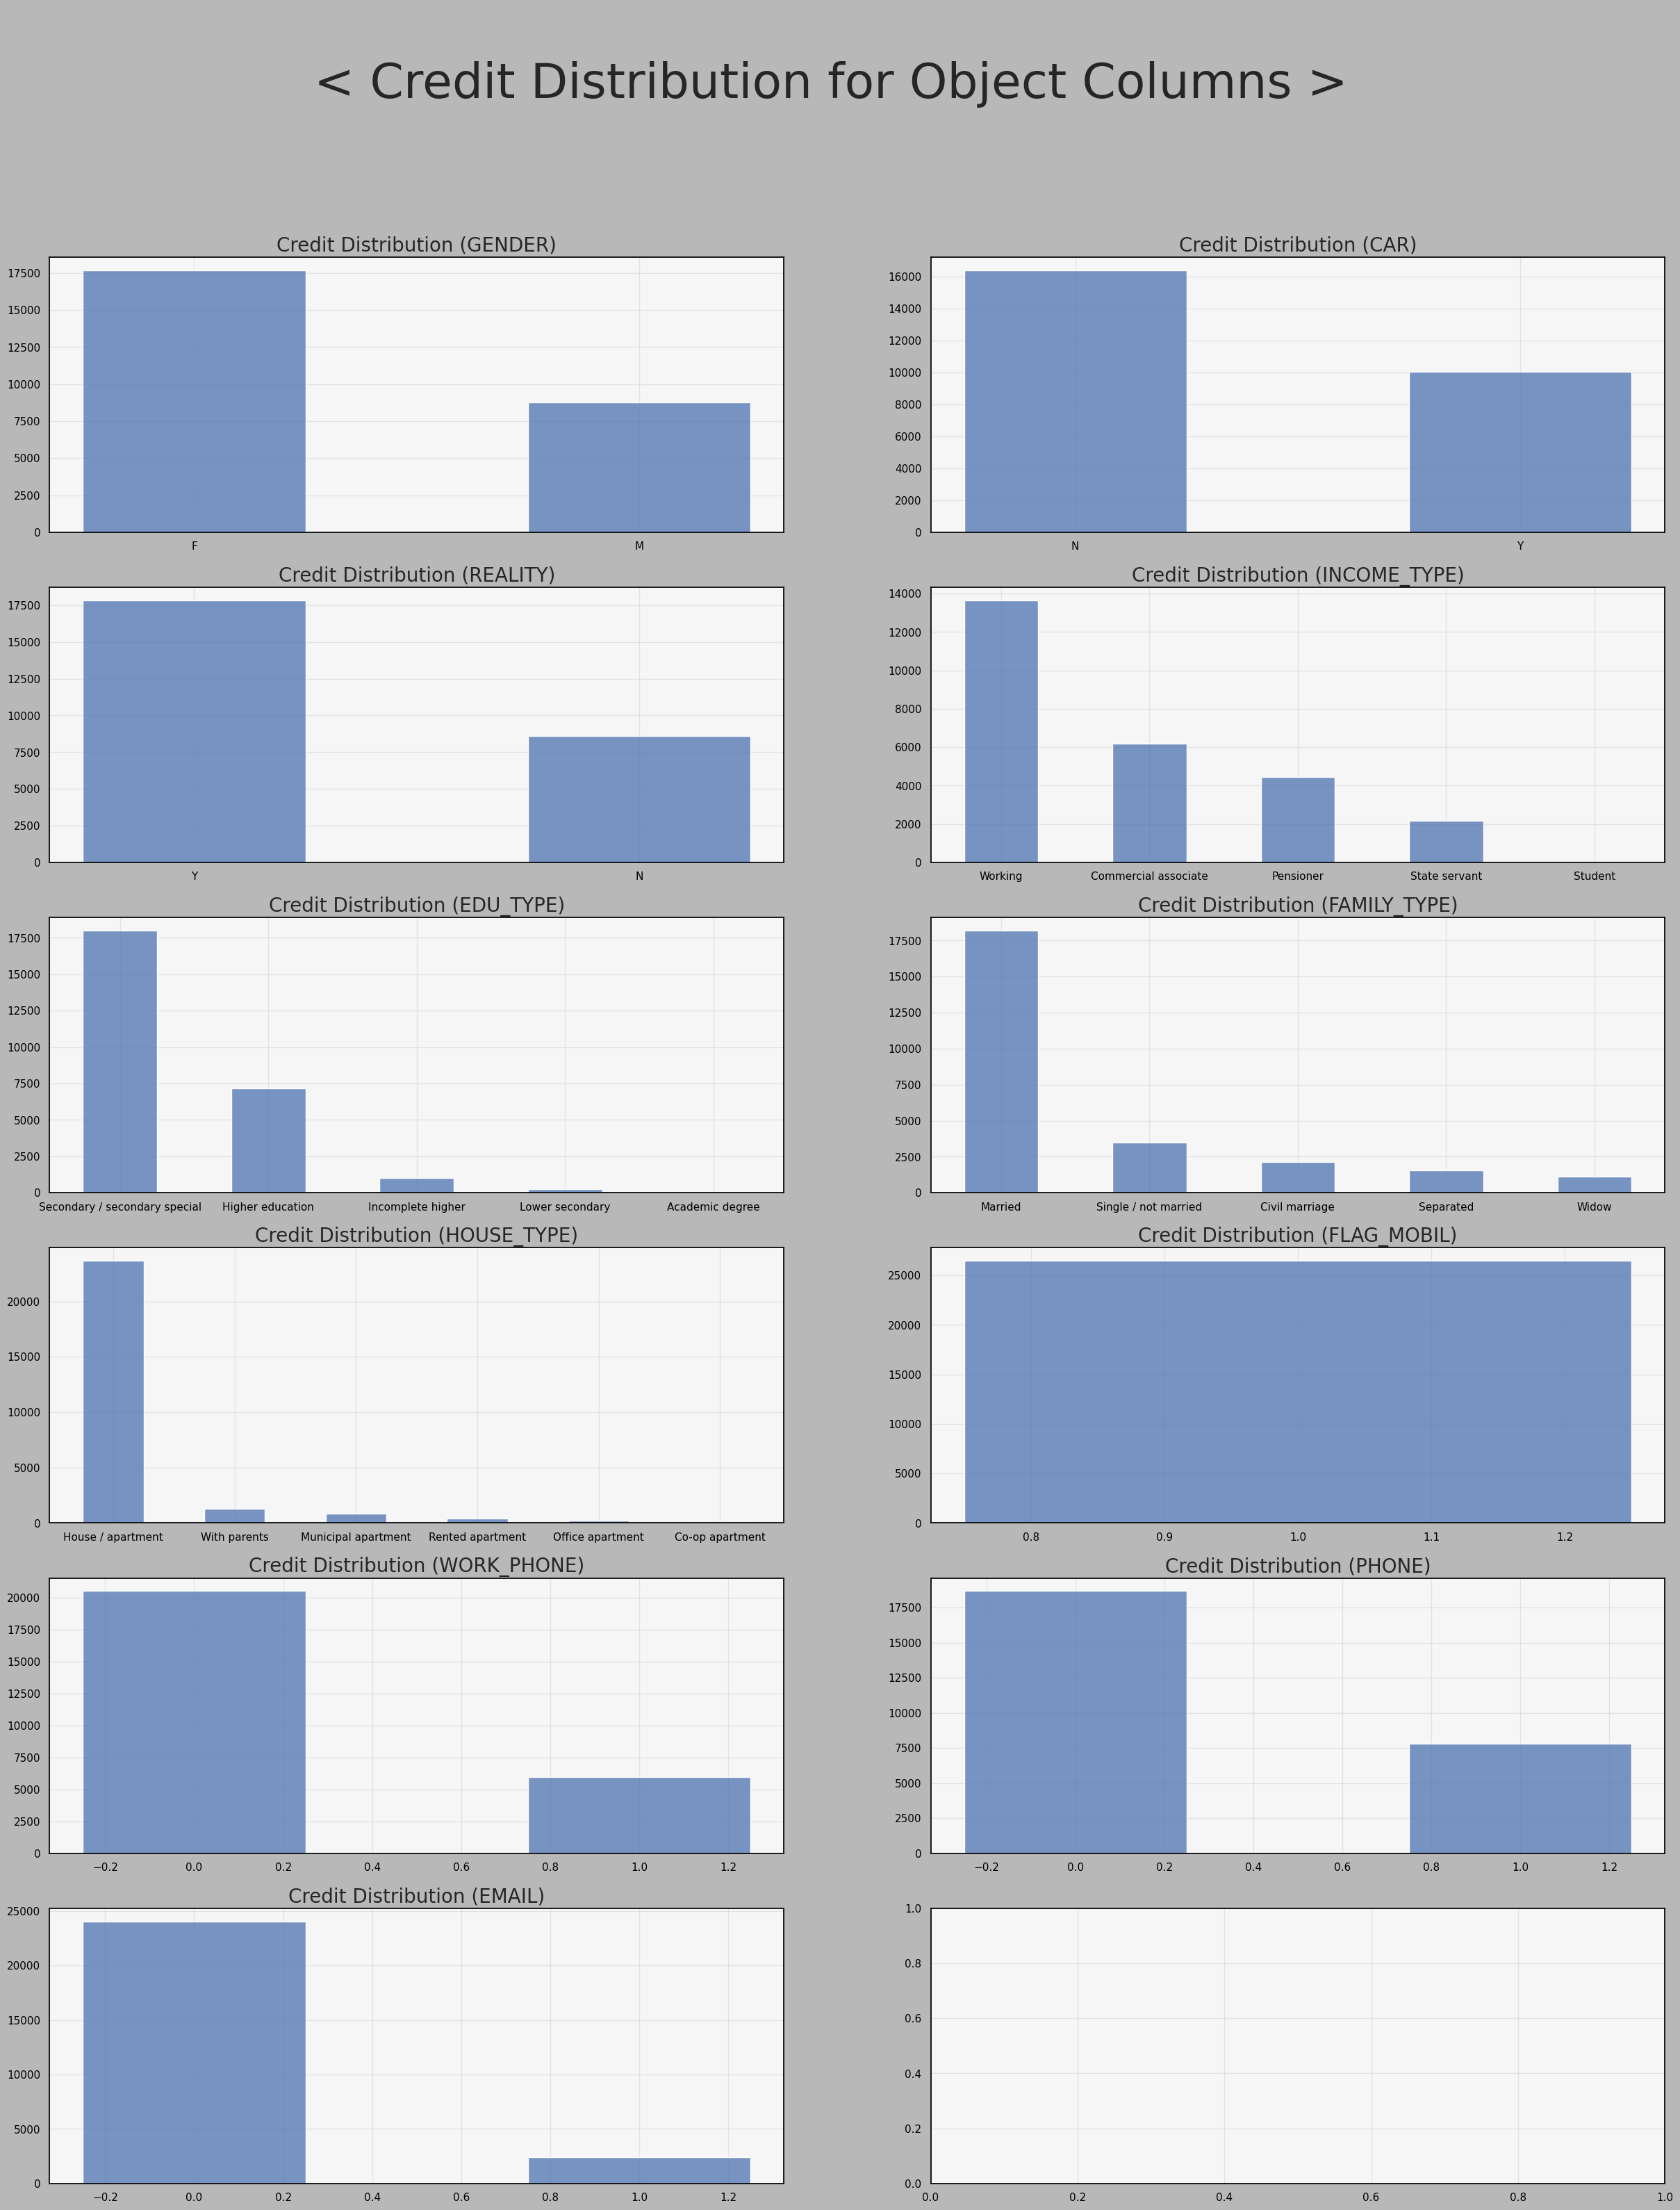

In [ ]:
# category columns EDA (without 'occyp_type')

cat_EDA_cols = train_cat.columns[:-2]

fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(30, 36))
axes = axes.flatten()

for i, col in enumerate(cat_EDA_cols):
  ax = axes[i]
  # sort column in descending order
  sorted_col = train_cat[col].value_counts().sort_values(ascending=False).index

  train_cat[col] = pd.Categorical(train_cat[col], sorted_col)

  sns.histplot(data=train_cat, x=col, binwidth=0.5, shrink=0.5,
              ax=ax, multiple="dodge")
  ax.set_title(f'Credit Distribution ({col.upper()})', fontsize=20)
  ax.set_ylabel("")
  ax.set_xlabel("")

plt.suptitle("\n< Credit Distribution for Object Columns >", fontsize=50)
plt.show()

In [ ]:
# 변수 occyp_type을 내림차순으로 정리합니다

sorted_col = train_cat["occyp_type"].value_counts().sort_values(ascending=False).index
train_cat["occyp_type"] = pd.Categorical(train_cat["occyp_type"], sorted_col)

In [ ]:
# 이진 데이터와 나머지 데이터로 나눠줍니다
bin_cols = ["gender", "car", "reality", "FLAG_MOBIL", "work_phone", "phone", "email"]

train_cat_bin = train_cat[bin_cols]
train_cat_bin["credit"] = train_cat["credit"]
train_cat_over = train_cat.drop(columns=bin_cols)

<ipython-input-14-a5ec12db367d>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_cat_bin["credit"] = train_cat["credit"]


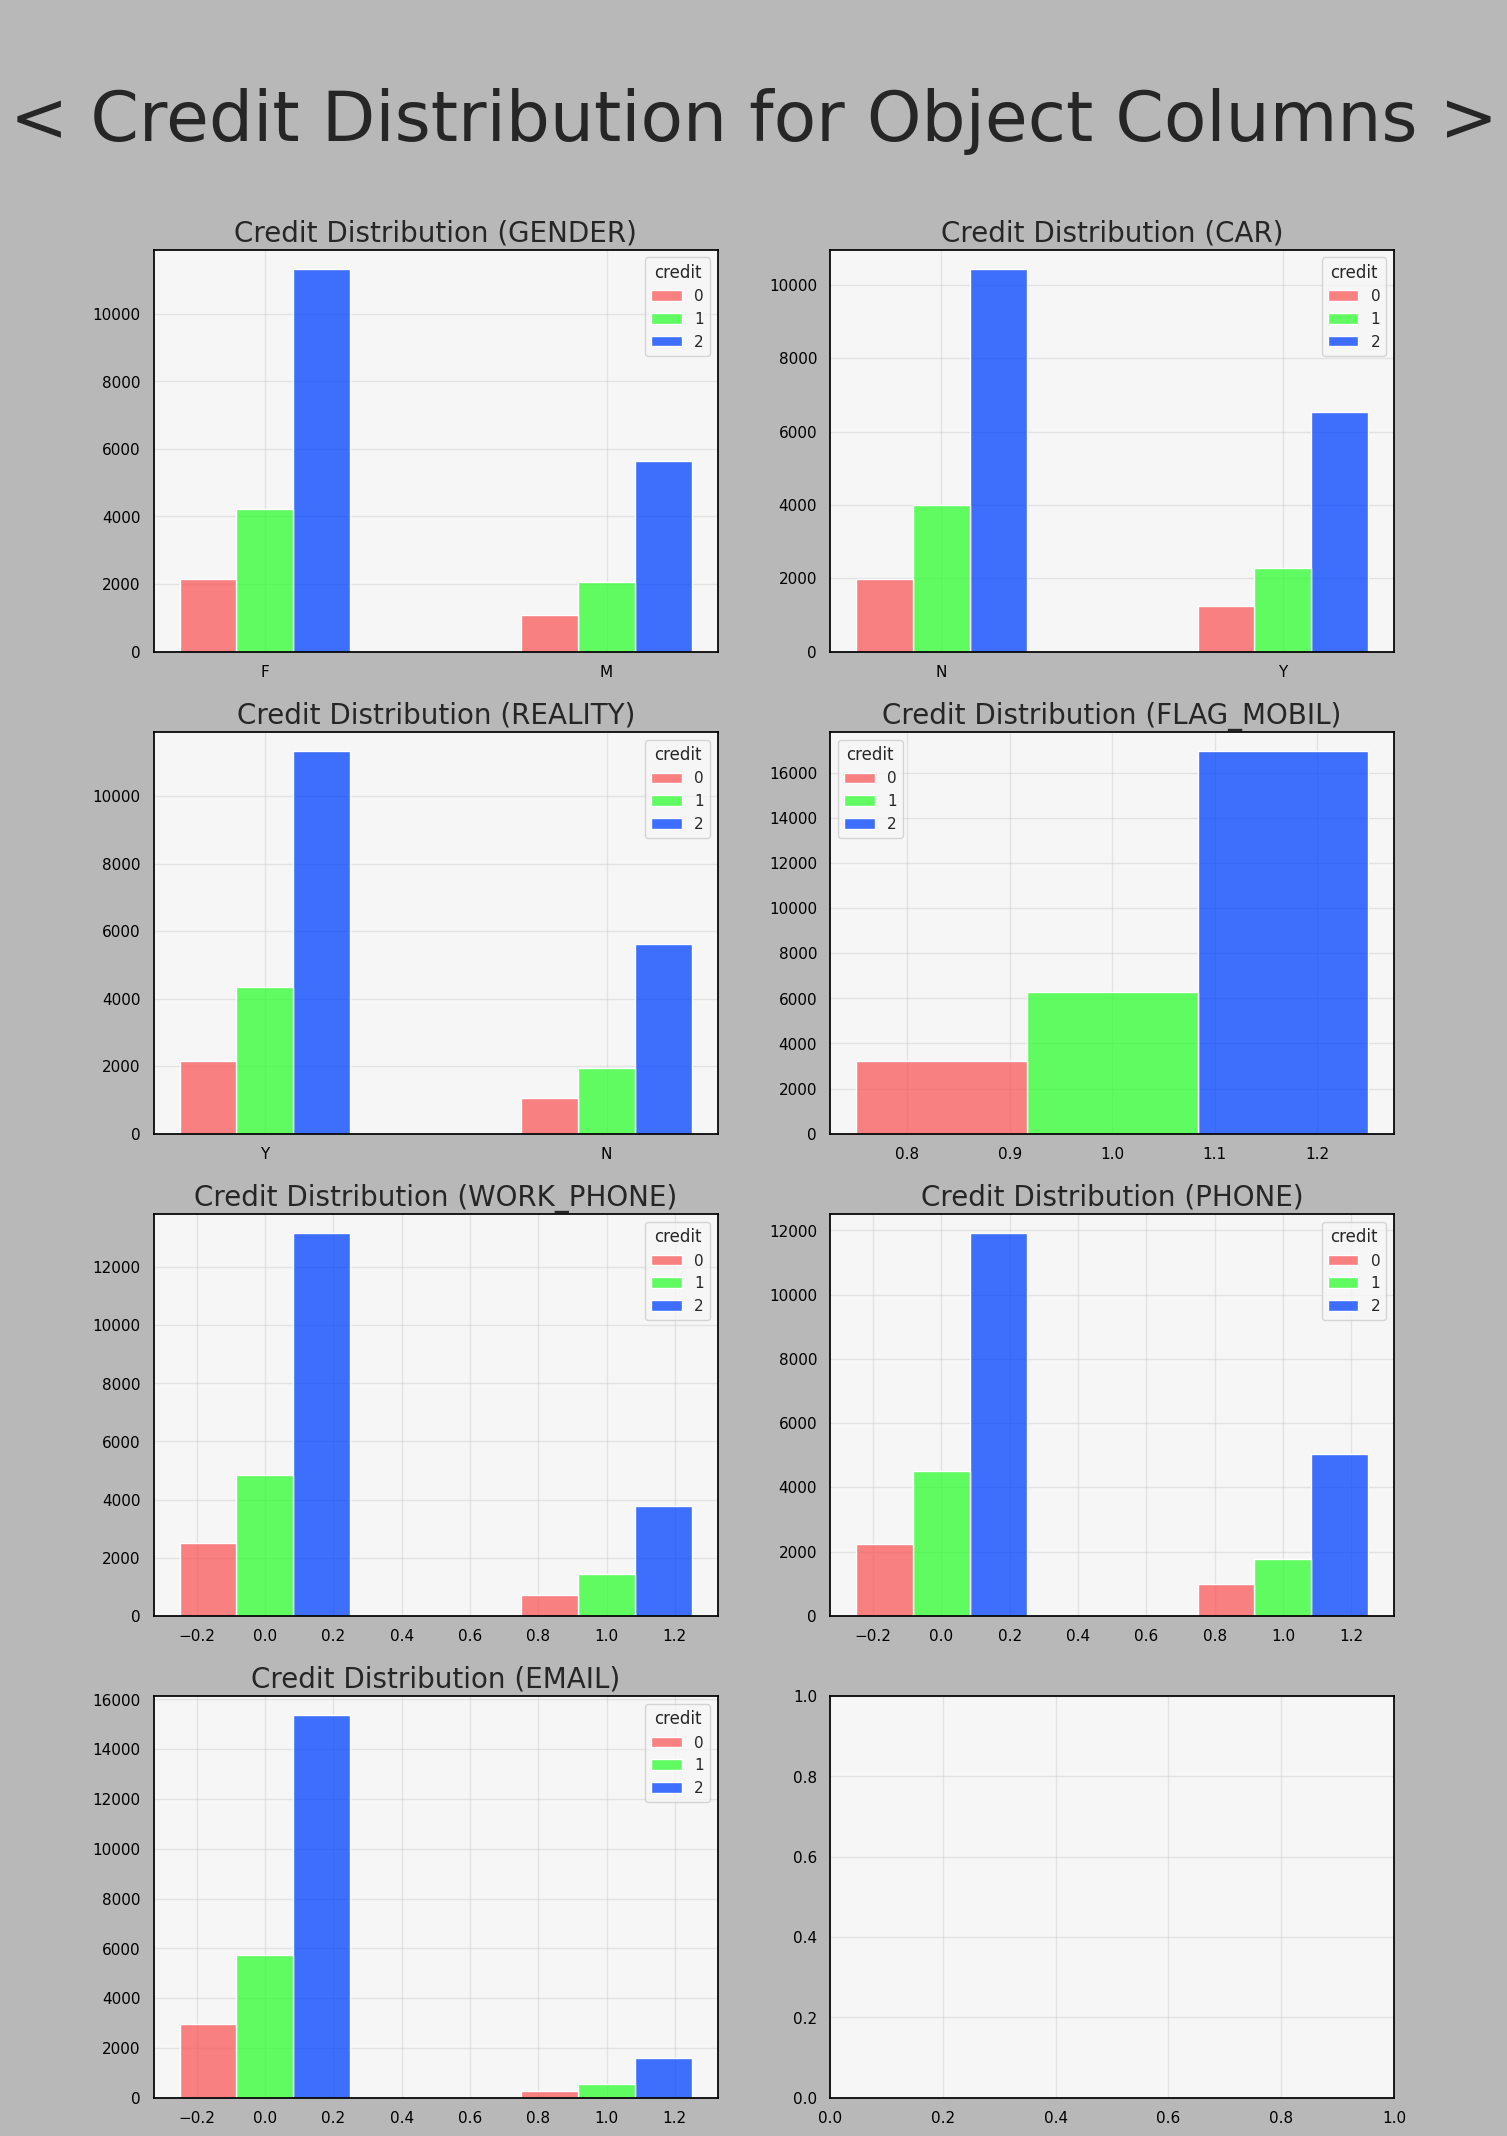

In [ ]:
# binary category columns EDA

cat_EDA_cols = train_cat_bin.columns[:-1]

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 24))
axes = axes.flatten()

for i, col in enumerate(cat_EDA_cols):
  ax = axes[i]

  sns.histplot(data=train_cat_bin, x=col, hue="credit", binwidth=0.5, shrink=0.5,
               palette=color, ax=ax, multiple="dodge", hue_order=[0, 1, 2])
  ax.set_title(f'Credit Distribution ({col.upper()})', fontsize=20)
  ax.set_ylabel("")
  ax.set_xlabel("")

plt.suptitle("\n< Credit Distribution for Object Columns >", fontsize=50)
plt.show()

### **2. pieplot**

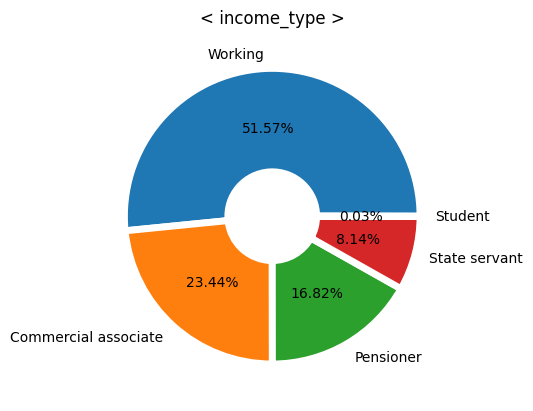

In [ ]:
ratio = train_cat_over["income_type"].value_counts()
labels = train_cat_over["income_type"].unique().categories
wedgeprops = {'width': 0.7, 'edgecolor': 'w', 'linewidth': 5}

plt.title("< income_type >")
plt.pie(x=ratio, labels=labels, autopct="%.2f%%", wedgeprops=wedgeprops)
plt.show()

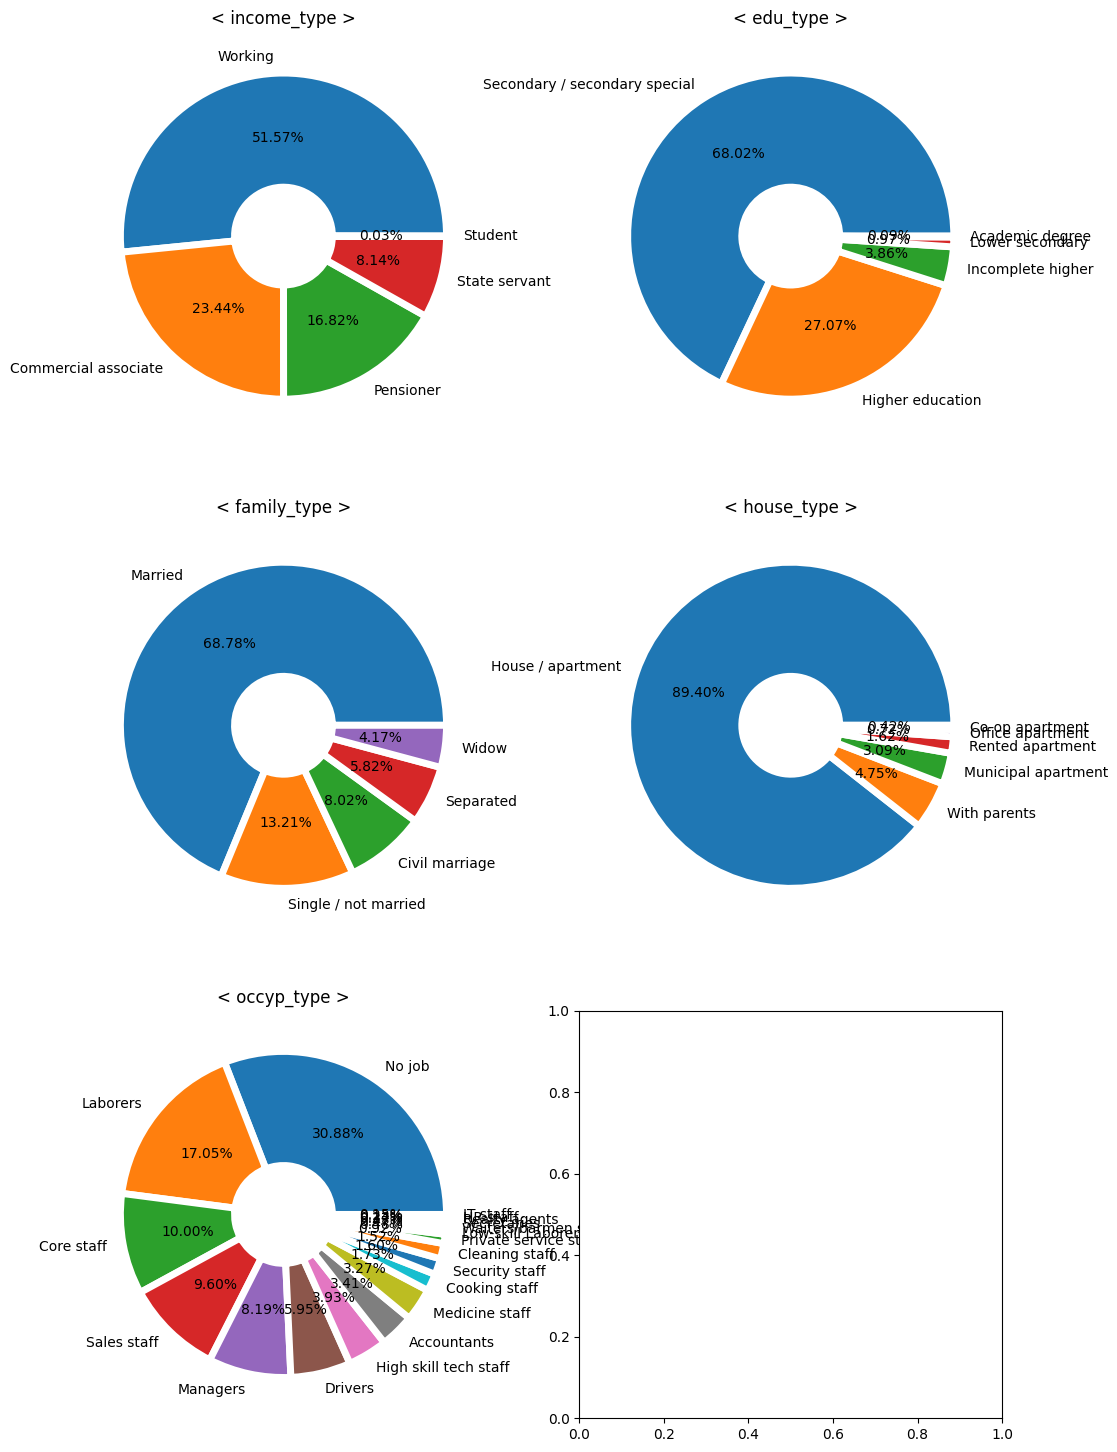

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 18))
axes = axes.flatten()
columns = train_cat_over.columns[:-1]

for i, col in enumerate(columns):
  ratio = train_cat_over[col].value_counts()
  labels = train_cat_over[col].unique().categories
  wedgeprops = {'width': 0.7, 'edgecolor': 'w', 'linewidth': 5}

  axes[i].set_title(f"< {col} >")
  axes[i].pie(x=ratio, labels=labels, autopct="%.2f%%", wedgeprops=wedgeprops)
plt.show()

### **3. `occyp_type` 변수 확인하기**

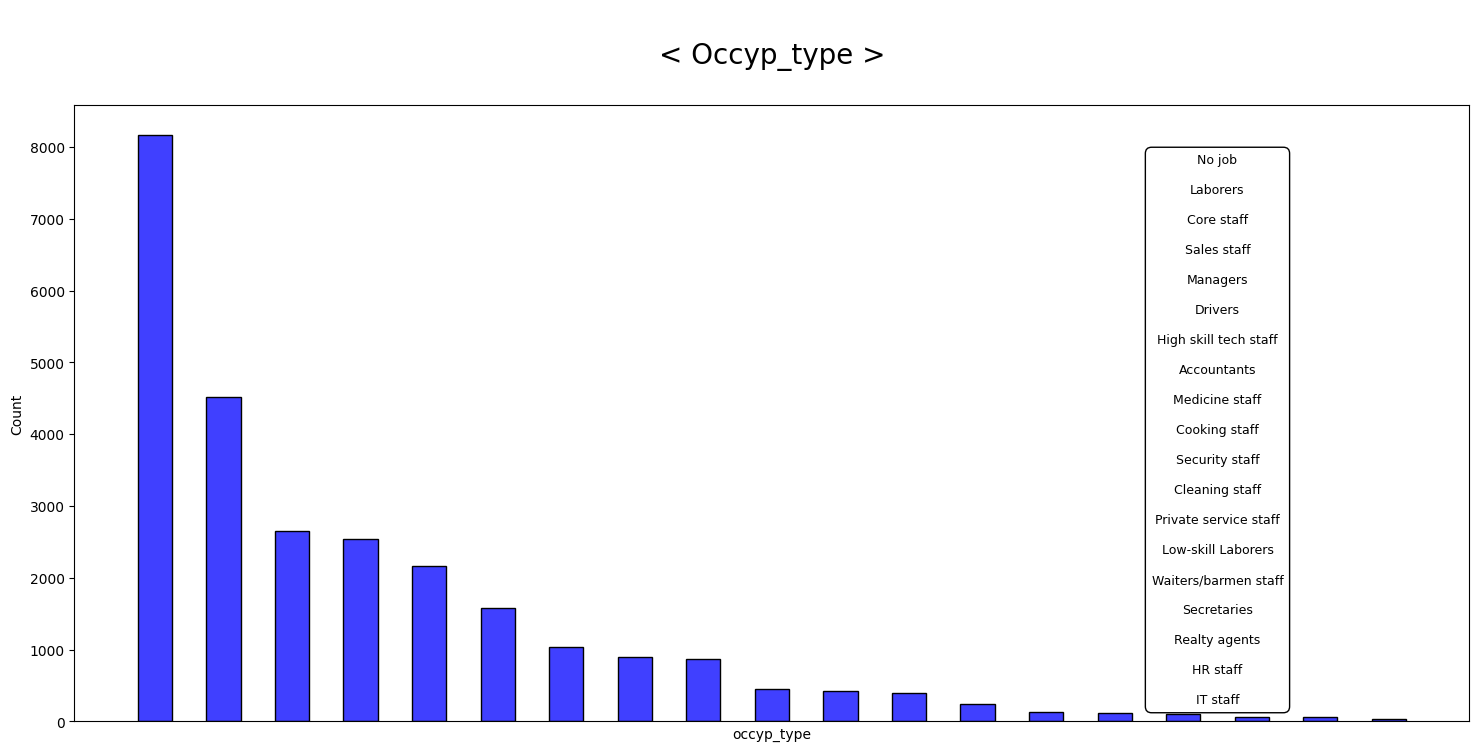

In [ ]:
plt.figure(figsize=(18,8))

sns.histplot(data=train_cat_over, x="occyp_type", binwidth=0.5, shrink=0.5,
             color="blue")
plt.xticks([])

plt.text(x=len(sorted_col)//2 + 6.5, y=250, s='\n\n'.join(sorted_col), fontsize=9,
         ha='center', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))
plt.title('\n< Occyp_type >', pad=30, fontsize=20)

plt.show()

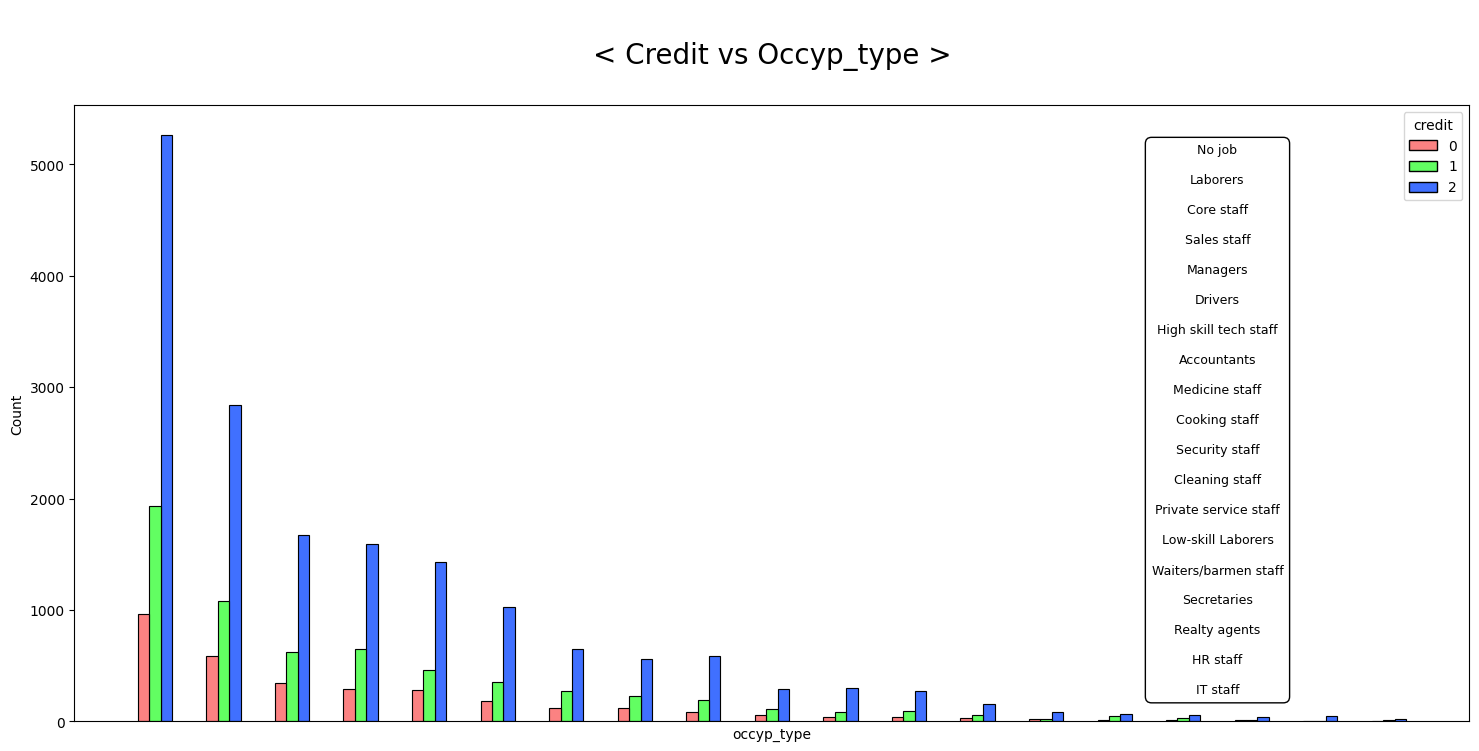

In [ ]:
plt.figure(figsize=(18,8))

sns.histplot(data=train_cat_over, x="occyp_type", hue="credit", binwidth=0.5,
             shrink=0.5, palette=color, multiple="dodge", hue_order=[0, 1, 2])
plt.xticks([])

plt.text(x=len(sorted_col)//2 + 6.5, y=250, s='\n\n'.join(sorted_col), fontsize=9,
         ha='center', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))
plt.title('\n< Credit vs Occyp_type >', pad=30, fontsize=20)

plt.show()

In [ ]:
# tabulate 모듈을 설치합니다
!pip install tabulate

In [ ]:
from tabulate import tabulate

output_table = []

occyps = train_cat_over['occyp_type'].value_counts().index

dfs = [train_cat_over[train_cat_over['occyp_type'] == occyps[i]] for i in range(len(occyps))]

for i, df in enumerate(dfs):
  output_table.append([occyps[i],
                      f'{round((len(df) / len(train_cat_over)) * 100, 2)}%',
                      round(df["credit"].value_counts(normalize=True) * 100, 2).astype("str") + "%"])

print(tabulate(output_table, headers=['Occyp Type', 'Proportion', 'Credit Distribution'], tablefmt='grid'))

+-----------------------+--------------+-----------------------------+
| Occyp Type            | Proportion   | Credit Distribution         |
+=======================+==============+=============================+
| No job                | 30.88%       | 2.0    64.45%               |
|                       |              | 1.0    23.72%               |
|                       |              | 0.0    11.83%               |
|                       |              | Name: credit, dtype: object |
+-----------------------+--------------+-----------------------------+
| Laborers              | 17.05%       | 2.0    63.03%               |
|                       |              | 1.0    23.98%               |
|                       |              | 0.0    12.99%               |
|                       |              | Name: credit, dtype: object |
+-----------------------+--------------+-----------------------------+
| Core staff            | 10.0%        | 2.0    63.38%               |
|     